# 🚗 AutoTec

---

## Proyecto Final — Big Data IICG 2026

---

## Introducción

En el contexto del mercado de vehículos usados, la definición de precios continúa siendo una tarea compleja debido a la gran cantidad de variables que influyen sobre el valor comercial de un automóvil.

Tradicionalmente, muchas decisiones de valorización se realizan utilizando criterios subjetivos o experiencias previas, lo que puede generar diferencias importantes respecto al comportamiento real del mercado.

Frente a este escenario, el presente proyecto tuvo como objetivo desarrollar un tablero de indicadores orientado al apoyo de decisiones tácticas mediante el análisis de datos reales del mercado automotriz.

Para ello, se utilizó una base consolidada de vehículos que incorpora variables relacionadas con características técnicas, nivel de uso y atributos comerciales.

Durante el desarrollo del proyecto se identificó que el precio de mercado no depende exclusivamente del kilometraje, sino que está condicionado por múltiples factores que interactúan simultáneamente.

Por esta razón, el enfoque inicial centrado únicamente en depreciación fue redefinido hacia un modelo de análisis orientado a **estimación del valor de mercado de vehículos usados**.

El resultado final corresponde a un conjunto de indicadores (KPI) diseñados para responder preguntas específicas del negocio y facilitar procesos de valorización basados en evidencia.






| Nivel           | KPI                                              | Objetivo                                                                                                                             | Frecuencia | Datos utilizados                                                     | Indicador principal                                                             |
| --------------- | ------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------ | ---------- | -------------------------------------------------------------------- | ------------------------------------------------------------------------------- |
| **Estratégico** | Concentración del mercado por marca              | Identificar el dominio y participación de las principales marcas dentro del mercado de vehículos usados.                             | Semestral  | Marca, cantidad de publicaciones.                                    | % de participación de mercado por marca.                                        |
| **Estratégico** | Tendencia del precio promedio de vehículos       | Analizar la evolución del valor promedio de los vehículos a través del tiempo para detectar alzas, caídas o estabilidad del mercado. | Anual      | Año, precio.                                                         | Precio promedio anual.                                                          |
| **Estratégico** | Pérdida de valor por kilómetro                   | Medir el impacto del uso del vehículo sobre su valor comercial y cuantificar la depreciación asociada al kilometraje.                | Trimestral | Kilometraje, precio.                                                 | Precio promedio por tramo de kilometraje.                                       |
| **Táctico**     | Valor de mercado por combustible y nivel de uso  | Identificar qué combinaciones de combustible y nivel de uso generan mayor o menor valor comercial.                                   | Mensual    | Precio, combustible, rango de kilometraje.                           | Precio promedio por combustible y nivel de uso.                                 |
| **Táctico**     | Posicionamiento de precios por marca             | Comparar el rango de precios y el precio promedio de cada marca para identificar posicionamiento competitivo y dispersión comercial. | Mensual    | Marca, precio mínimo, promedio y máximo.                             | Banda de precios por marca.                                                     |
| **Táctico**     | Retención de valor por marca                     | Determinar qué marcas conservan mejor su valor relativo respecto al mercado general.                                                 | Mensual    | Marca, precio promedio de marca, precio promedio mercado.            | Índice de retención de valor (base mercado = 100).                              |
| **Operacional** | Alertas de publicaciones fuera de rango estimado | Detectar vehículos cuyo precio publicado se desvía significativamente del valor esperado según el modelo predictivo.                 | Diaria     | Precio real, precio estimado, kilometraje, año, marca y combustible. | % de vehículos fuera de rango, alertas moderadas y críticas.                    |
| **Operacional** | Matriz de alertas por antigüedad y precio        | Identificar publicaciones potencialmente sobrevaloradas, especialmente vehículos antiguos con precios altos.                         | Diaria     | Antigüedad del vehículo, precio, marca, modelo y ciudad.             | Clasificación por cuadrantes: Normal, Gama Alta, Observar y Alerta de Revisión. |


In [10]:
# ==========================================
# 1. CARGA DE LIBRERÍAS Y DATOS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

ruta = "/home/jovyan/work/autotec/final/autos1.csv"

df = pd.read_csv(ruta)

print("Datos cargados correctamente")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.head()

Datos cargados correctamente
Filas: 1685
Columnas: 18


,_id,cat_combustible,categoria_precio,ciudad,combustible,fecha_captura,foto_url,grupo,kilometraje,marca,modelo,precio,rango_kilometraje,tipo_marca,url,uso_anual_estimado,usuario,year
0,6a1c90b4b2f827e18bad5008,0,Medio,araucania,bencina,2026-05-31 19:47:03,NaN,AutoTec,44387.0,changan,Cs55 1.5t Elite 4x2 At 5p,15490000.0,Bajo,generalista,https://automoviles.emol.com/venta/autos/chang...,22193.500000,Luz Azocar,2024
1,6a1c90b4b2f827e18bad4ffc,0,Medio,santiago,bencina,2026-05-31 19:47:03,NaN,AutoTec,75500.0,changan,Cs75,8000000.0,Medio,generalista,https://automoviles.emol.com/venta/autos/chang...,8388.888889,Luz Azocar,2017
2,6a1c90b3b2f827e18bad4f11,0,Medio,araucania,bencina,2026-05-31 19:47:58,NaN,AutoTec,92300.0,changan,Cx70 1.6,7190000.0,Medio,generalista,https://automoviles.emol.com/venta/autos/chang...,11537.500000,Luz Azocar,2018
3,6a1c90b2b2f827e18bad4e9e,0,Medio,santiago,bencina,2026-05-31 19:48:40,NaN,AutoTec,87626.0,chery,Arrizo 1.5,6950000.0,Medio,generalista,https://automoviles.emol.com/venta/autos/chery...,29208.666667,Luz Azocar,2023
4,6a1c90b2b2f827e18bad4ea4,0,Medio,santiago,bencina,2026-05-31 19:47:10,NaN,AutoTec,45050.0,chery,Tiggo 1.5t Glx 4x2 Cvt At 5p,12480000.0,Bajo,generalista,https://automoviles.emol.com/venta/autos/chery...,9010.000000,Luz Azocar,2021


In [10]:
# ==========================================
# 1. CARGA DE LIBRERÍAS Y DATOS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

ruta = "/home/jovyan/work/autotec/final/autos1.csv"

df = pd.read_csv(ruta)

print("Datos cargados correctamente")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.head()

Datos cargados correctamente
Filas: 1685
Columnas: 18


,_id,cat_combustible,categoria_precio,ciudad,combustible,fecha_captura,foto_url,grupo,kilometraje,marca,modelo,precio,rango_kilometraje,tipo_marca,url,uso_anual_estimado,usuario,year
0,6a1c90b4b2f827e18bad5008,0,Medio,araucania,bencina,2026-05-31 19:47:03,NaN,AutoTec,44387.0,changan,Cs55 1.5t Elite 4x2 At 5p,15490000.0,Bajo,generalista,https://automoviles.emol.com/venta/autos/chang...,22193.500000,Luz Azocar,2024
1,6a1c90b4b2f827e18bad4ffc,0,Medio,santiago,bencina,2026-05-31 19:47:03,NaN,AutoTec,75500.0,changan,Cs75,8000000.0,Medio,generalista,https://automoviles.emol.com/venta/autos/chang...,8388.888889,Luz Azocar,2017
2,6a1c90b3b2f827e18bad4f11,0,Medio,araucania,bencina,2026-05-31 19:47:58,NaN,AutoTec,92300.0,changan,Cx70 1.6,7190000.0,Medio,generalista,https://automoviles.emol.com/venta/autos/chang...,11537.500000,Luz Azocar,2018
3,6a1c90b2b2f827e18bad4e9e,0,Medio,santiago,bencina,2026-05-31 19:48:40,NaN,AutoTec,87626.0,chery,Arrizo 1.5,6950000.0,Medio,generalista,https://automoviles.emol.com/venta/autos/chery...,29208.666667,Luz Azocar,2023
4,6a1c90b2b2f827e18bad4ea4,0,Medio,santiago,bencina,2026-05-31 19:47:10,NaN,AutoTec,45050.0,chery,Tiggo 1.5t Glx 4x2 Cvt At 5p,12480000.0,Bajo,generalista,https://automoviles.emol.com/venta/autos/chery...,9010.000000,Luz Azocar,2021


In [12]:
# ============================================
# 4. LIMPIEZA DE DATOS
# ============================================

# eliminar columna que no aporta al análisis

df = df.drop(
columns=["foto_url"]
)

# completar uso anual

df["uso_anual_estimado"] = (
df["uso_anual_estimado"]

.fillna(

df["uso_anual_estimado"]

.median()

)

)

# tipos numéricos

cols_num = [

"precio",
"kilometraje",
"year",
"uso_anual_estimado"

]

for c in cols_num:

    df[c] = pd.to_numeric(
        df[c],
        errors="coerce"
    )

# eliminar registros inválidos

df = df.dropna(
subset=[
"precio",
"kilometraje",
"year"
]
)

print("Dataset final:")

print(df.shape)

Dataset final:
(1685, 17)


# Tablero Estratégico

presenta una visión general del mercado automotriz usado, enfocada en indicadores estratégicos para apoyar la toma de decisiones.

<br>

# Métricas principales

Este conjunto de indicadores resume el comportamiento general del mercado analizado y entrega una visión ejecutiva del estado actual del inventario vehicular.

- **Vehículos totales:** cantidad total de publicaciones consideradas en el análisis.
- **Precio promedio:** valor promedio del mercado de vehículos usados.
- **Kilometraje promedio:** nivel promedio de uso de los vehículos analizados.
- **Marca líder:** marca con mayor presencia dentro de la muestra estudiada.

<br>

Estos indicadores permiten establecer una línea base del mercado antes de profundizar en el análisis estratégico relacionado con participación de marcas, evolución de precios y comportamiento de depreciación.

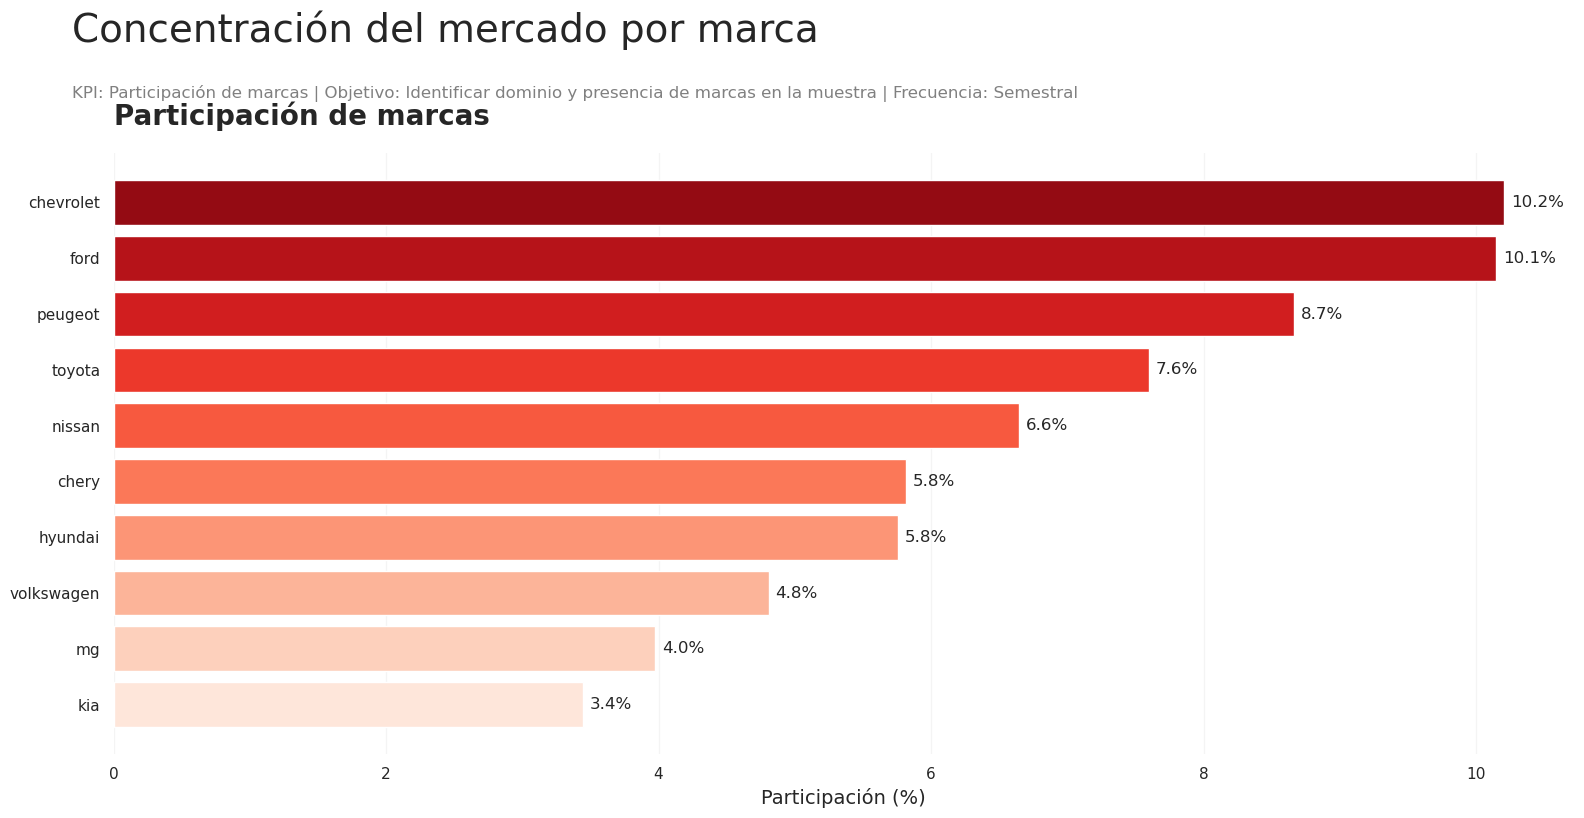

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# ===========================
# KPI 1 — Concentración mercado por marca
# ===========================

# Calcular participación (%)
df_est = (
    df["marca"]
    .value_counts(normalize=True)
    .mul(100)
    .head(10)
    .reset_index()
)

df_est.columns = ["marca", "participacion"]

# Ordenar
df_est = df_est.sort_values(
    by="participacion",
    ascending=True
)

# Estilo
sns.set_theme(
    style="whitegrid"
)

fig, ax = plt.subplots(
    figsize=(16,8)
)

# Colores rojo degradado
colors = sns.color_palette(
    "Reds",
    len(df_est)
)

# Gráfico
bars = ax.barh(
    df_est["marca"],
    df_est["participacion"],
    color=colors
)

# Título principal
plt.suptitle(
    "Concentración del mercado por marca",
    fontsize=28,
    fontweight="normal",
    x=0.05,
    ha="left",
    y=1.02
)

# Subtítulo KPI
plt.figtext(
    0.05,
    0.91,
    "KPI: Participación de marcas | Objetivo: Identificar dominio y presencia de marcas en la muestra | Frecuencia: Semestral",
    fontsize=12,
    color="gray"
)

# Título interno
ax.set_title(
    "Participación de marcas",
    fontsize=20,
    fontweight="bold",
    loc="left",
    pad=20
)

# Ejes
ax.set_xlabel(
    "Participación (%)",
    fontsize=14
)

ax.set_ylabel("")

# Grilla
ax.grid(
    axis="x",
    alpha=0.2
)

ax.grid(
    axis="y",
    visible=False
)

# Etiquetas
for i, v in enumerate(df_est["participacion"]):

    ax.text(
        v + 0.05,
        i,
        f"{v:.1f}%",
        va="center",
        fontsize=12
    )

# Limpiar bordes
sns.despine(
    left=True,
    bottom=True
)

# Espacios
plt.tight_layout()

plt.show()

##  Descripción

Este gráfico de barras horizontales muestra la participación porcentual de las principales marcas dentro de la muestra analizada. En el eje vertical se presentan las marcas y en el eje horizontal su porcentaje de participación. La marca con mayor presencia es Chevrolet, con un **10,2%**, seguida muy de cerca por Ford, con un **10,1%**. En contraste, la menor participación dentro del Top 10 corresponde a **Kia, con un 3,4%**.

---

##  Interpretación

Este gráfico cuenta que la oferta del mercado no se distribuye de manera uniforme entre las marcas, sino por un grupo de marcas con presencia relativamente repartida, aunque con dos líderes claros: **Ford y Chevrolet**.

El gráfico muestra una concentración moderada del mercado por marca. Ford y Chevrolet lideran con **10,1% cada una**, lo que las sitúa como principales referentes de oferta y volumen en la muestra. Detrás aparece un segundo bloque competitivo —**Peugeot, Toyota y Nissan**— con participaciones relevantes (entre aproximadamente **6,6% y 8,7%**), que sostienen la cobertura de mercado en segmentos clave.

El resto de marcas (**Chery, Hyundai, Volkswagen, MG y Kia**) presentan participaciones menores y operan en un nivel secundario, aportando diversidad pero sin disputar la posición de liderazgo.

---

## Propuesta estratégica

### Priorizar marcas líderes en el portafolio

Conviene fortalecer su disponibilidad, visibilidad comercial y peso dentro del inventario para sostener volumen.

### Revisar la cobertura de marcas de baja participación

Marcas como **Kia, MG, Volkswagen** y otras con menor peso deberían analizarse para decidir si se mantienen como nicho, se reposicionan o se reducen en la estrategia de portafolio.

### Asignar recursos según liderazgo de marca

Las marcas con mayor participación deben recibir mayor prioridad en campañas, alianzas y compras de inventario, porque son las que más influyen en el comportamiento global del mercado.


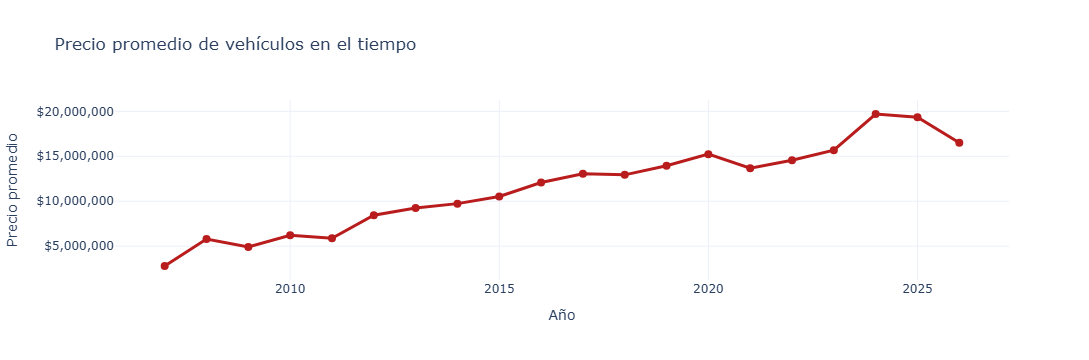

In [13]:
# =========================
# KPI 2
# =========================

import plotly.express as px

df_time = (
    df.dropna(subset=["year", "precio"])
      .query("year >= 2000")
      .groupby("year", as_index=False)["precio"]
      .mean()
      .sort_values("year")
)

fig = px.line(
    df_time,
    x="year",
    y="precio",
    markers=True,
    title="Precio promedio de vehículos en el tiempo",
)

fig.update_traces(
    line=dict(color="#B91C1C", width=3),
    marker=dict(size=8)
)

fig.update_layout(
    xaxis_title="Año",
    yaxis_title="Precio promedio",
    hovermode="x unified",
    template="plotly_white"
)

fig.update_yaxes(
    tickprefix="$",
    tickformat=",.0f"
)

fig.show()

##  Descripción

Este gráfico de líneas muestra la tendencia del precio promedio de los vehículos a través del tiempo. En el eje horizontal se presentan los años y en el eje vertical el precio promedio. El punto más bajo se observa al inicio del período, con un valor cercano a los **5 millones de pesos**, mientras que el punto más alto se encuentra en los años más recientes, superando los **20 millones de pesos**.

---

##  Interpretación

El mercado ha ido encareciéndose de manera sostenida, lo que sugiere un aumento general en el valor promedio de los vehículos y una posible presión al alza en los precios de publicación.

Aunque hay pequeños retrocesos en algunos años, como en el año **2021**, la tendencia de fondo no cambia: el mercado se mueve hacia valores más altos y el crecimiento se acelera especialmente al final del período.

Este comportamiento indica que los vehículos más recientes mantienen una valorización superior dentro del mercado, mientras que la oferta de vehículos antiguos presenta precios considerablemente menores.

---

##  Propuesta estratégica

### Ajustar la estrategia de precios al alza

Si el promedio de mercado viene subiendo, los precios de publicación deben revisarse periódicamente para evitar quedar por debajo de los valores observados en el mercado.

### Priorizar inventario con mayor valor de reventa

Conviene enfocar la captación en vehículos que sigan esta tendencia positiva y mantengan una mejor valorización en el tiempo.

### Fortalecer la estimación de precios de mercado

La tendencia observada puede utilizarse como referencia para mejorar los modelos de valorización de vehículos usados, considerando el efecto que tiene el año del vehículo sobre su precio esperado.

### Anticipar oportunidades comerciales

El crecimiento sostenido de los precios permite identificar segmentos con mayor potencial de rentabilidad y orientar la estrategia comercial hacia vehículos con una valorización más favorable.


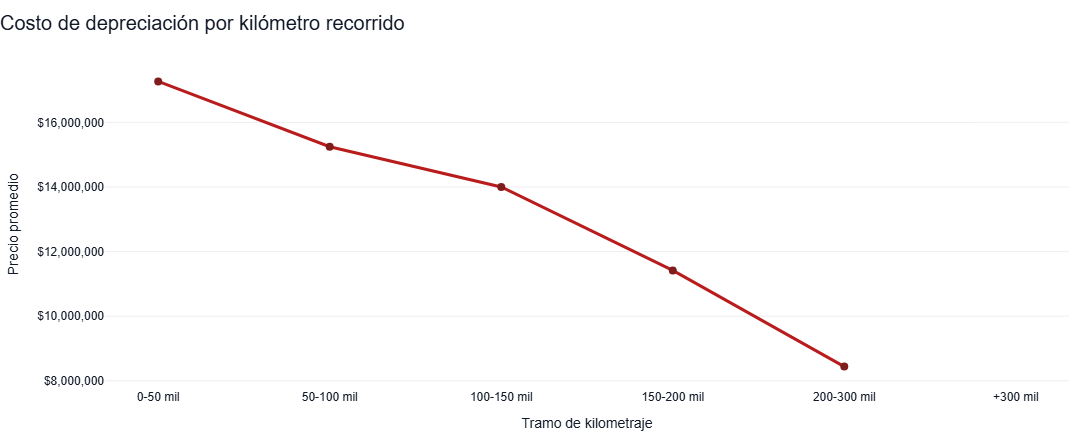

In [14]:
# =========================
# KPI 3
# =========================

import pandas as pd
import plotly.express as px

df_km = df.dropna(subset=["kilometraje", "precio"]).copy()

bins = [0, 50000, 100000, 150000, 200000, 300000, float("inf")]
labels = ["0-50 mil", "50-100 mil", "100-150 mil", "150-200 mil", "200-300 mil", "+300 mil"]

df_km["tramo_km"] = pd.cut(
    df_km["kilometraje"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_dep_km = (
    df_km.groupby("tramo_km", as_index=False)["precio"]
    .mean()
)

fig = px.line(
    df_dep_km,
    x="tramo_km",
    y="precio",
    markers=True,
    title="Costo de depreciación por kilómetro recorrido"
)

fig.update_traces(
    line=dict(color="#B91C1C", width=3),
    marker=dict(size=8, color="#7F1D1D"),
    hovertemplate="<b>Tramo:</b> %{x}<br><b>Precio promedio:</b> $%{y:,.0f}<extra></extra>"
)

fig.update_layout(
    xaxis_title="Tramo de kilometraje",
    yaxis_title="Precio promedio",
    hovermode="x unified",
    template="plotly_white",
    height=440,
    title=dict(x=0, xanchor="left", font=dict(size=20, color="#111827")),
    font=dict(family="Inter, sans-serif", color="#111827"),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=20, r=20, t=60, b=20)
)

fig.update_yaxes(
    tickprefix="$",
    tickformat=",.0f",
    gridcolor="rgba(156, 163, 175, 0.18)"
)

fig.update_xaxes(showgrid=False)

fig.show()

### Descripción

Este gráfico de líneas presenta la relación entre el tramo de kilometraje recorrido y el precio promedio de los vehículos. En el eje horizontal se muestran los distintos rangos de kilometraje, mientras que en el eje vertical se representa el precio promedio. El valor más alto se observa en los vehículos con entre 0 y 50 mil kilómetros, con un precio promedio cercano a los 18 millones de pesos. Por el contrario, el valor más bajo corresponde a los vehículos con entre 200 y 300 mil kilómetros, cuyo precio promedio se aproxima a los 9 millones de pesos.

### Interpretación

La lectura principal es que el kilometraje actúa como un factor directo de depreciación: los vehículos con menor recorrido concentran los valores promedio más altos, mientras que los tramos de mayor uso pierden valor de forma progresiva.

Además, la caída se vuelve más marcada en los tramos altos de kilometraje, lo que sugiere que, desde cierto nivel de uso, el mercado castiga con mayor fuerza el precio del vehículo, afectando directamente el potencial de rentabilidad del portafolio.

### Propuesta estratégica

* Orientar la estrategia de abastecimiento hacia vehículos de menor kilometraje: son los que preservan mejor el valor y fortalecen la calidad del inventario.
* Definir límites de compra por tramo de uso: el comportamiento del gráfico justifica establecer umbrales de kilometraje para controlar el riesgo de depreciación.
* A nivel estratégico, se recomienda segmentar el inventario de vehículos según su kilometraje y establecer políticas diferenciadas de precio y comercialización para cada tramo.
* Asimismo, se sugiere utilizar este KPI como apoyo en la toma de decisiones relacionadas con la compra, venta y gestión del inventario, identificando oportunamente aquellos vehículos de mayor kilometraje que podrían requerir estrategias de rotación más ágiles.


# Tablero Táctico

Este tablero presenta una visión táctica del mercado automotriz usado, enfocada en apoyar decisiones de gestión, segmentación y posicionamiento comercibr>

# Objetivo del nivel táctico

Transformar los datos del mercado en información útil para optimizar la composición del inventario, identificar oportunidades comerciales y mejorar el posicionamiento de las marcas dentro del mercado.

<br>

Este nivel permite analizar patrones intermedios de comportamiento, evaluar retención de valor, dispersión de precios, segmentación comercial y detectar oportunidades de mejora en decisiones de abastecimiento y comercialización.o

In [36]:
from IPython.display import display, HTML

display(HTML("""
<div style="
    background-color:#063B70;
    color:white;
    padding:22px;
    border-radius:14px;
    font-size:16px;
    line-height:1.7;
    margin-bottom:20px;
    box-shadow:0 8px 18px rgba(0,0,0,0.18);
">
    <b>Para este KPI, la variable rango_kilometraje fue segmentada en tres niveles de uso:</b><br>
    • <b>Bajo:</b> menos de 50.000 km<br>
    • <b>Medio:</b> entre 50.000 y 119.999 km<br>
    • <b>Alto:</b> 120.000 km o más
</div>
"""))

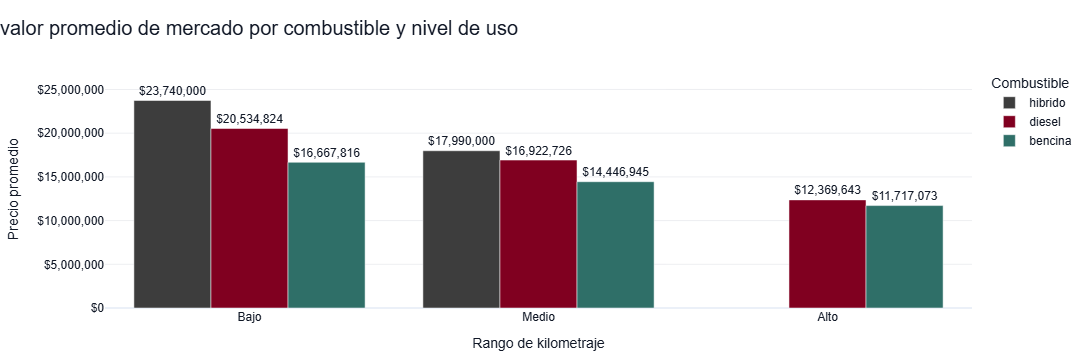

In [19]:
df_tac = df.dropna(subset=["precio", "combustible", "rango_kilometraje"]).copy()

df_plot = (
    df_tac.groupby(["rango_kilometraje", "combustible"], as_index=False)["precio"]
    .mean()
    .sort_values("precio", ascending=False)
    .head(10)
)

paleta_tablero = {
    "bencina": "#2F6F68",
    "diesel": "#800020",
    "hibrido": "#3D3D3D",
    "híbrido": "#3D3D3D",
    "electrico": "#0066CC",
    "eléctrico": "#0066CC"
}

fig = px.bar(
    df_plot,
    x="rango_kilometraje",
    y="precio",
    color="combustible",
    barmode="group",
    text="precio",
    category_orders={"rango_kilometraje": ["Bajo", "Medio", "Alto"]},
    color_discrete_map=paleta_tablero,
    title="valor promedio de mercado por combustible y nivel de uso"
)

fig.update_traces(
    texttemplate="$%{text:,.0f}",
    textposition="outside",
    cliponaxis=False
)

fig.update_layout(
    template="plotly_white",
    height=500,
    title=dict(x=0, xanchor="left", font=dict(size=20, color="#111827")),
    font=dict(family="Inter, sans-serif", color="#111827"),
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis_title="Rango de kilometraje",
    yaxis_title="Precio promedio",
    legend_title="Combustible",
    margin=dict(l=20, r=20, t=70, b=20)
)

fig.update_yaxes(tickprefix="$", tickformat=",.0f", gridcolor="rgba(156, 163, 175, 0.18)")
fig.update_xaxes(showgrid=False)

fig.show()

## Descripción

Este gráfico de barras presenta el **valor promedio de mercado de los vehículos según tipo de combustible y nivel de uso**. En el eje horizontal se muestran los distintos niveles de uso (**Bajo, Medio y Alto**), mientras que en el eje vertical se representa el **precio promedio de los vehículos**. Cada color corresponde a una categoría de combustible (**híbrido, diésel y bencina**).

Se observa que los **vehículos híbridos mantienen los precios promedio más altos** en los niveles de uso bajo y medio, alcanzando aproximadamente **$23,7 millones** y **$18 millones**, respectivamente. Los vehículos **diésel presentan valores intermedios**, mientras que los vehículos **a bencina muestran los precios promedio más bajos** en casi todos los segmentos.

Además, se evidencia una disminución progresiva del precio promedio a medida que aumenta el nivel de uso, reflejando el efecto de la depreciación sobre el valor del vehículo.

---

## Interpretación

El análisis evidencia que **el combustible actúa como un factor relevante en la conservación del valor del vehículo dentro del mercado**.

Los vehículos híbridos muestran una mayor capacidad de mantener precios elevados incluso cuando aumenta el nivel de uso, lo que podría estar asociado a una mayor demanda por eficiencia energética, menor percepción de obsolescencia y mejor posicionamiento tecnológico.

Por otra parte, los vehículos a bencina presentan una depreciación más pronunciada conforme aumenta el uso acumulado. En el caso de los vehículos diésel, se observa un comportamiento intermedio, conservando parte de su valor pero con una disminución progresiva más marcada que los híbridos.

Estos resultados sugieren que el mercado no solo responde al kilometraje o nivel de uso, sino también al tipo de tecnología y eficiencia asociada al combustible del vehículo.

---

## Propuesta estratégica

**Priorizar la adquisición de vehículos híbridos de bajo y medio uso:**
Estos segmentos muestran una mayor conservación del valor promedio y representan oportunidades para mantener mejores márgenes comerciales.

**Aplicar estrategias de valorización diferenciadas por combustible:**
Definir políticas de precios independientes para híbridos, diésel y bencina considerando que presentan velocidades de depreciación distintas.

**Establecer reglas de descuento según nivel de uso:**
Los vehículos con mayor desgaste deberían tener criterios de precio más dinámicos para mejorar la rotación del inventario.

**Potenciar campañas comerciales segmentadas:**
Destacar los híbridos como una categoría de mayor retención de valor y utilizar el diésel como alternativa de equilibrio entre precio y desempeño.

**Incorporar este KPI en decisiones de compra e inventario:**
Utilizar el comportamiento observado para orientar el abastecimiento hacia categorías con mejor conservación de valor y menor riesgo de depreciación.


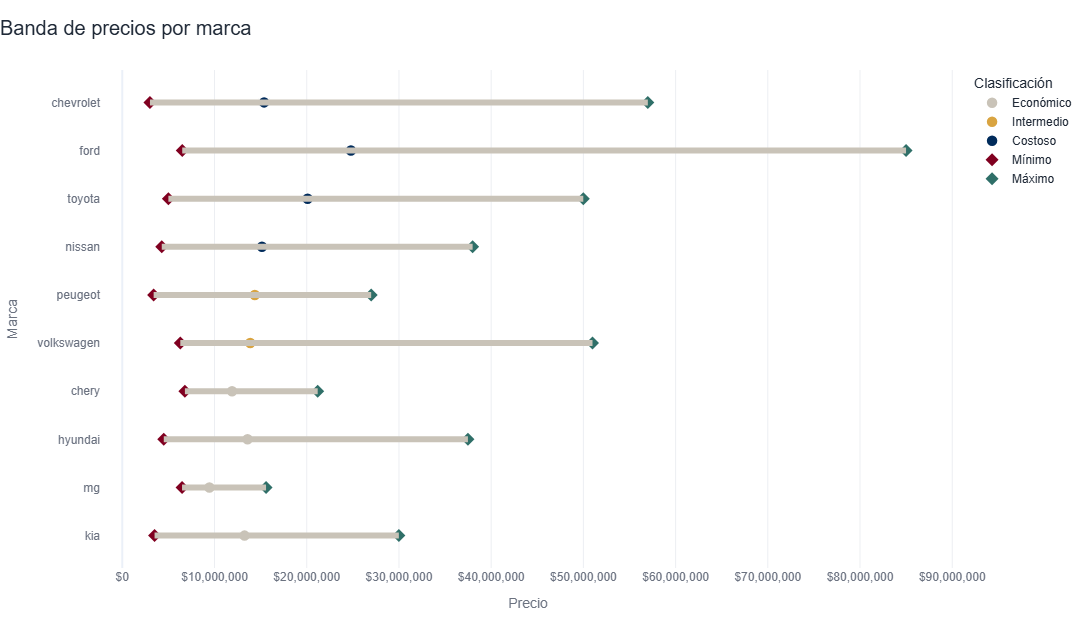

In [33]:
# ==========================================
# KPI 2 — Posicionamiento de precios por marca
# Versión igual al gráfico original
# ==========================================

import pandas as pd
import plotly.graph_objects as go

# 1. Preparar datos
df_marca = df.dropna(subset=["marca", "precio"]).copy()
df_marca["precio"] = pd.to_numeric(df_marca["precio"], errors="coerce")
df_marca = df_marca.dropna(subset=["precio"])

# 2. Top 10 marcas por cantidad de autos
top10_marcas = (
    df_marca["marca"]
    .value_counts()
    .head(10)
    .index
)

df_marca_top = df_marca[df_marca["marca"].isin(top10_marcas)].copy()

# 3. Calcular mínimo, promedio y máximo por marca
resumen_marca = (
    df_marca_top
    .groupby("marca", as_index=False)["precio"]
    .agg(
        minimo="min",
        promedio="mean",
        maximo="max"
    )
)

# 4. Clasificar el precio promedio en 3 niveles
q1 = resumen_marca["promedio"].quantile(1/3)
q2 = resumen_marca["promedio"].quantile(2/3)

def clasificar_promedio(valor):
    if valor <= q1:
        return "Económico"
    elif valor <= q2:
        return "Intermedio"
    else:
        return "Costoso"

resumen_marca["clasificacion"] = resumen_marca["promedio"].apply(clasificar_promedio)

# 5. Orden igual al dashboard original: por presencia de marca
orden_marcas = list(top10_marcas)

resumen_marca["marca"] = pd.Categorical(
    resumen_marca["marca"],
    categories=orden_marcas[::-1],
    ordered=True
)

resumen_marca = resumen_marca.sort_values("marca")

# 6. Paleta original
paleta = {
    "rango": "#C9C3B8",
    "Económico": "#C9C3B8",
    "Intermedio": "#D9A441",
    "Costoso": "#002B5B",
    "Mínimo": "#800020",
    "Máximo": "#2F6F68",
    "texto": "#1F2937",
    "texto_suave": "#6B7280",
    "grid": "rgba(148, 163, 184, 0.18)",
    "fondo": "#FFFFFF"
}

fig = go.Figure()

# 7. Líneas de rango mínimo-máximo
for _, row in resumen_marca.iterrows():
    fig.add_shape(
        type="line",
        x0=row["minimo"],
        x1=row["maximo"],
        y0=row["marca"],
        y1=row["marca"],
        xref="x",
        yref="y",
        line=dict(
            color=paleta["rango"],
            width=6
        )
    )

# 8. Puntos de promedio por clasificación
for categoria in ["Económico", "Intermedio", "Costoso"]:
    df_cat = resumen_marca[resumen_marca["clasificacion"] == categoria]

    fig.add_trace(
        go.Scatter(
            x=df_cat["promedio"],
            y=df_cat["marca"],
            mode="markers",
            name=categoria,
            marker=dict(
                size=12,
                color=paleta[categoria],
                line=dict(color="white", width=1.5)
            ),
            customdata=df_cat[["minimo", "maximo", "clasificacion"]],
            hovertemplate=(
                "<b>Marca:</b> %{y}<br>"
                "<b>Clasificación:</b> %{customdata[2]}<br>"
                "<b>Promedio:</b> $%{x:,.0f}<br>"
                "<b>Mínimo:</b> $%{customdata[0]:,.0f}<br>"
                "<b>Máximo:</b> $%{customdata[1]:,.0f}<extra></extra>"
            )
        )
    )

# 9. Mínimo
fig.add_trace(
    go.Scatter(
        x=resumen_marca["minimo"],
        y=resumen_marca["marca"],
        mode="markers",
        name="Mínimo",
        marker=dict(
            size=10,
            color=paleta["Mínimo"],
            symbol="diamond"
        ),
        hovertemplate="<b>Marca:</b> %{y}<br><b>Mínimo:</b> $%{x:,.0f}<extra></extra>"
    )
)

# 10. Máximo
fig.add_trace(
    go.Scatter(
        x=resumen_marca["maximo"],
        y=resumen_marca["marca"],
        mode="markers",
        name="Máximo",
        marker=dict(
            size=10,
            color=paleta["Máximo"],
            symbol="diamond"
        ),
        hovertemplate="<b>Marca:</b> %{y}<br><b>Máximo:</b> $%{x:,.0f}<extra></extra>"
    )
)

# 11. Layout
fig.update_layout(
    template="plotly_white",
    height=620,
    title=dict(
        text="Banda de precios por marca",
        x=0,
        xanchor="left",
        font=dict(size=20, color=paleta["texto"])
    ),
    font=dict(
        family="Inter, sans-serif",
        color=paleta["texto"]
    ),
    plot_bgcolor=paleta["fondo"],
    paper_bgcolor=paleta["fondo"],
    xaxis_title="Precio",
    yaxis_title="Marca",
    legend_title="Clasificación",
    margin=dict(l=20, r=20, t=70, b=20)
)

fig.update_xaxes(
    tickprefix="$",
    tickformat=",.0f",
    showgrid=True,
    gridcolor=paleta["grid"],
    tickfont=dict(color=paleta["texto_suave"]),
    title_font=dict(color=paleta["texto_suave"])
)

fig.update_yaxes(
    showgrid=False,
    tickfont=dict(color=paleta["texto_suave"]),
    title_font=dict(color=paleta["texto_suave"])
)

fig.show()

In [34]:
# ==========================================
# TABLA — CLUSTER COMERCIAL POR MARCA
# ==========================================

cluster_marca = resumen_marca.copy()

# Cantidad de publicaciones por marca
publicaciones = (
    df_marca.groupby("marca")
    .size()
    .reset_index(name="N° publicaciones")
)

cluster_marca = cluster_marca.merge(
    publicaciones,
    on="marca",
    how="left"
)

# Dejar columnas necesarias
cluster_marca = cluster_marca[
    ["marca", "promedio", "clasificacion", "N° publicaciones"]
].copy()

cluster_marca = cluster_marca.rename(
    columns={
        "marca": "Marca",
        "promedio": "Precio promedio",
        "clasificacion": "Cluster"
    }
)

cluster_marca = cluster_marca.sort_values("Precio promedio", ascending=True)

display(cluster_marca)

,Marca,Precio promedio,Cluster,N° publicaciones
1,mg,9.447761e+06,Económico,67
4,chery,1.190143e+07,Económico,98
0,kia,1.325759e+07,Económico,58
3,hyundai,1.358402e+07,Económico,97
2,volkswagen,1.387556e+07,Intermedio,81
7,peugeot,1.436999e+07,Intermedio,146
5,nissan,1.514674e+07,Costoso,112
9,chevrolet,1.537971e+07,Costoso,172
6,toyota,2.009613e+07,Costoso,128
8,ford,2.479529e+07,Costoso,171


## Descripción

Este gráfico presenta la **banda de precios por marca**, mostrando para cada fabricante tres puntos de referencia: el **precio mínimo**, el **precio promedio** y el **precio máximo** observado dentro del mercado analizado. El eje horizontal representa el precio y el eje vertical las distintas marcas evaluadas.

La línea horizontal entre ambos extremos permite visualizar el rango de variación de precios dentro de cada marca, mientras que el punto central indica el comportamiento promedio del mercado.

Se observa que algunas marcas presentan una banda de precios considerablemente más amplia que otras, destacando especialmente **Ford**, que registra el mayor rango entre valores mínimos y máximos. En contraste, marcas como **MG** y **Chery** muestran una dispersión más reducida, concentrando sus precios en intervalos más acotados.

---

## Interpretación

Este indicador permite evaluar el **nivel de dispersión comercial y estabilidad de precios por marca**.

Las marcas con bandas más amplias evidencian una mayor heterogeneidad dentro de su oferta, lo que puede explicarse por diferencias entre modelos, versiones, antigüedad, equipamiento o posicionamiento comercial.

Por otro lado, una banda más estrecha sugiere un comportamiento más uniforme del mercado y una menor variabilidad en la valorización.

También se aprecia que algunas marcas presentan un precio promedio relativamente alto acompañado de una amplitud importante en sus rangos, indicando oportunidades comerciales diferenciadas dentro de una misma categoría.

Desde una perspectiva táctica, una dispersión elevada puede significar tanto oportunidades de margen como mayor complejidad para definir precios competitivos.

---

## Propuesta estratégica

**Implementar políticas de precio diferenciadas por marca:**
Las marcas con alta dispersión requieren modelos de valorización más específicos para evitar errores de publicación.

**Priorizar análisis de bandas amplias para identificar oportunidades comerciales:**
Marcas con mayor distancia entre mínimos y máximos pueden ofrecer mejores espacios para optimizar márgenes.

**Definir estrategias de inventario según estabilidad de precios:**
Marcas con menor dispersión permiten proyectar precios con mayor certeza y reducir riesgo comercial.

**Complementar este KPI con variables de modelo, año y kilometraje:**
La amplitud observada debe interpretarse junto con otros atributos que afectan directamente el valor final del vehículo.

**Utilizar la banda de precios como apoyo para negociación de compra:**
Conocer el rango esperado permite detectar vehículos potencialmente sobrevalorados o subvalorados antes de incorporarlos al inventario.


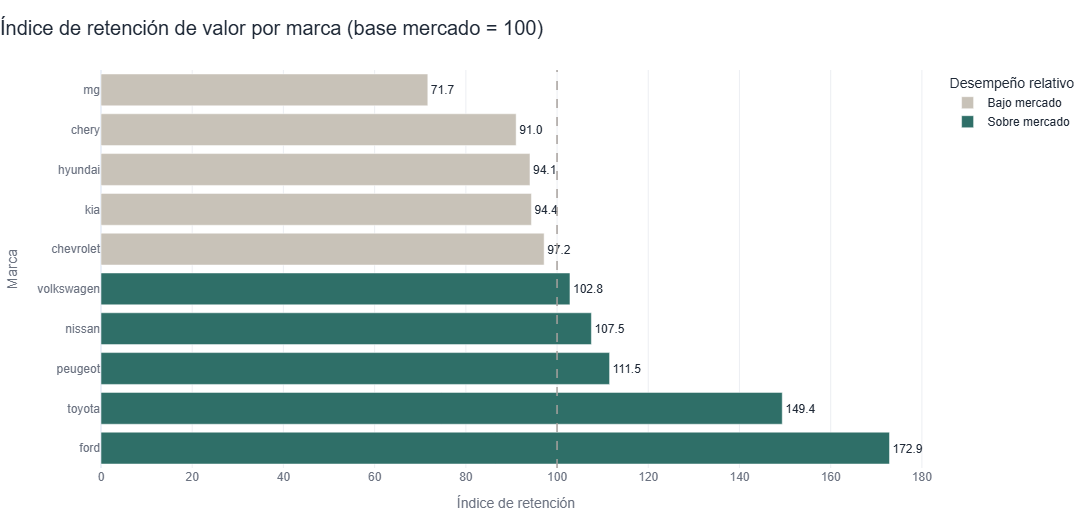

In [23]:
# ==========================================
# KPI 3: Retención de valor por marca
# Top 10 marcas principales por cantidad
# ==========================================

df_ret = df.dropna(subset=["marca", "precio"]).copy()

# 1. Seleccionar las 10 marcas con mayor presencia en la base
top_10_marcas = (
    df_ret["marca"]
    .value_counts()
    .head(10)
    .index
)

df_ret_top = df_ret[df_ret["marca"].isin(top_10_marcas)].copy()

# 2. Calcular precio mediano por marca
resumen_ret = (
    df_ret_top.groupby("marca", as_index=False)["precio"]
    .median()
    .rename(columns={"precio": "precio_mediano"})
)

# 3. Base mercado = mediana de las marcas principales
mediana_mercado = resumen_ret["precio_mediano"].median()

resumen_ret["indice_retencion"] = (
    resumen_ret["precio_mediano"] / mediana_mercado * 100
)

# 4. Clasificación sobre/bajo mercado
resumen_ret["categoria"] = resumen_ret["indice_retencion"].apply(
    lambda x: "Sobre mercado" if x >= 100 else "Bajo mercado"
)

# 5. Ordenar para que se vea igual
resumen_ret = resumen_ret.sort_values("indice_retencion", ascending=True)

orden_marcas = resumen_ret["marca"].tolist()

paleta = {
    "sobre": "#2F6F68",
    "bajo": "#C8C2B8",
    "texto": "#1F2937",
    "texto_suave": "#6B7280",
    "grid": "rgba(148, 163, 184, 0.18)",
    "fondo": "#FFFFFF",
    "linea_base": "#A8A29E"
}

fig = px.bar(
    resumen_ret,
    x="indice_retencion",
    y="marca",
    orientation="h",
    text="indice_retencion",
    color="categoria",
    category_orders={"marca": orden_marcas},
    color_discrete_map={
        "Sobre mercado": paleta["sobre"],
        "Bajo mercado": paleta["bajo"]
    },
    title="Índice de retención de valor por marca"
)

fig.update_traces(
    texttemplate="%{text:.1f}",
    textposition="outside",
    cliponaxis=False
)

fig.add_vline(
    x=100,
    line_width=1.5,
    line_dash="dash",
    line_color=paleta["linea_base"]
)

fig.update_layout(
    template="plotly_white",
    height=520,
    title=dict(
        text="Índice de retención de valor por marca (base mercado = 100)",
        x=0,
        xanchor="left",
        font=dict(size=20, color=paleta["texto"])
    ),
    font=dict(
        family="Inter, sans-serif",
        color=paleta["texto"]
    ),
    plot_bgcolor=paleta["fondo"],
    paper_bgcolor=paleta["fondo"],
    xaxis_title="Índice de retención",
    yaxis_title="Marca",
    legend_title="Desempeño relativo",
    margin=dict(l=20, r=40, t=70, b=20)
)

fig.update_xaxes(
    showgrid=True,
    gridcolor=paleta["grid"],
    tickfont=dict(color=paleta["texto_suave"]),
    title_font=dict(color=paleta["texto_suave"])
)

fig.update_yaxes(
    showgrid=False,
    tickfont=dict(color=paleta["texto_suave"]),
    title_font=dict(color=paleta["texto_suave"])
)

fig.show()

## Descripción

Este gráfico presenta el **índice de retención de valor por marca**, utilizando como referencia el promedio del mercado igual a **100**. El eje horizontal representa el índice de retención y el eje vertical muestra las distintas marcas analizadas.

La línea vertical punteada indica el punto de referencia del mercado (**100**). Las marcas que superan ese valor presentan una conservación relativa del precio por encima del promedio general, mientras que aquellas bajo ese umbral muestran una retención de valor inferior.

Se observa que **Ford** registra el índice más alto (**172,9**), seguida por **Toyota (149,4)** y **Peugeot (111,5)**, indicando una fuerte capacidad para mantener su valor dentro del mercado. En contraste, marcas como **MG (71,7)**, **Chery (91,0)** e **Hyundai (94,1)** se posicionan por debajo del comportamiento promedio.

---

## Interpretación

Este indicador permite evaluar qué tan bien cada marca logra **conservar su valor relativo frente al mercado total**.

Las marcas con índice superior a **100** muestran una mayor fortaleza comercial, menor velocidad de depreciación y potencialmente una demanda más estable en el tiempo. Esto significa que los vehículos pertenecientes a estas categorías tienden a sostener precios más altos incluso frente al desgaste y envejecimiento.

Por otro lado, las marcas bajo el promedio presentan una pérdida de valor más acelerada, lo que podría estar asociado a factores como percepción de calidad, competencia de precios, posicionamiento o menor estabilidad de demanda.

Desde una perspectiva táctica, este KPI permite identificar qué marcas entregan mejores condiciones para proteger márgenes comerciales y reducir riesgo de depreciación.

---

## Propuesta estratégica

**Priorizar adquisición de marcas con índice superior al mercado:**
Marcas como Ford, Toyota y Peugeot presentan mejor capacidad de conservación del valor y podrían fortalecer la rentabilidad del inventario.

**Aplicar políticas diferenciadas de valorización por marca:**
No todas las marcas deben seguir la misma lógica de precios debido a diferencias en velocidad de depreciación.

**Ajustar metas comerciales según retención histórica:**
Las marcas con menor índice pueden requerir estrategias de rotación más rápidas y promociones específicas.

**Utilizar el índice como apoyo para decisiones de abastecimiento:**
Incorporar este indicador dentro del proceso de compra permite reducir exposición a categorías con mayor pérdida de valor.

**Complementar el análisis con variables de antigüedad y kilometraje:**
La retención observada debe interpretarse junto con otros factores que también afectan el precio final del vehículo.


# Nivel Operacional




In [26]:
# ==========================================
# KPI 1 — ALERTAS DE PRECIOS FUERA DE RANGO
# ==========================================

print("Alertas de Precios Fuera de Rango")

# LIMPIEZA
df_modelo = df.dropna(
    subset=[
        "precio",
        "kilometraje",
        "year",
        "marca",
        "combustible"
    ]
).copy()

# VARIABLES
X = df_modelo[
    [
        "kilometraje",
        "year",
        "marca",
        "combustible"
    ]
]

X = pd.get_dummies(
    X,
    columns=[
        "marca",
        "combustible"
    ],
    drop_first=True
)

X = X.astype(float)

y = df_modelo["precio"].astype(float)

# REGRESIÓN
X_b = np.c_[
    np.ones((len(X),1)),
    X.values
]

theta_best = (
    np.linalg.inv(
        X_b.T @ X_b
    )
    @ X_b.T
    @ y
)

y_pred = X_b @ theta_best

# MÉTRICAS
mae = np.mean(
    np.abs(
        y - y_pred
    )
)

rmse = np.sqrt(
    np.mean(
        (y-y_pred)**2
    )
)

print("\nMétricas del modelo")
print(f"MAE: ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")

# ALERTAS
df_alertas = pd.DataFrame({
    "Real": y,
    "Predicho": y_pred
})

df_alertas["Diferencia"] = (
    df_alertas["Real"]
    -
    df_alertas["Predicho"]
)

def clasificar(v):

    if abs(v)<=mae:
        return "Aceptable"

    elif abs(v)<=2*mae:
        return "Moderado"

    else:
        return "Crítico"

df_alertas["Riesgo"] = (
    df_alertas["Diferencia"]
    .apply(clasificar)
)

# %
fuera = (
    (
        df_alertas["Riesgo"]
        !=
        "Aceptable"
    )
    .mean()
    *
    100
)

print(f"\n% Fuera rango: {fuera:.1f}%")

# RESUMEN
df_riesgo = (
    df_alertas["Riesgo"]
    .value_counts()
    .reset_index()
)

df_riesgo.columns=[
    "Nivel",
    "Cantidad"
]

df_riesgo["Porcentaje"]=(
    df_riesgo["Cantidad"]
    /
    len(df_alertas)
    *
    100
)

display(df_riesgo)

Alertas de Precios Fuera de Rango

Métricas del modelo
MAE: $4,468,691
RMSE: $6,536,417

% Fuera rango: 36.2%


,Nivel,Cantidad,Porcentaje
0,Aceptable,1075,63.798220
1,Moderado,442,26.231454
2,Crítico,168,9.970326


### Descripción

Se realizó un modelo de regresión para estimar el precio esperado de cada vehículo considerando variables relevantes del mercado, como kilometraje, año, marca y combustible. A partir de este modelo, se comparó el precio publicado con el valor estimado para identificar posibles desviaciones.

### Interpretación

Este KPI permite detectar publicaciones cuyo precio real se desvía del valor estimado por el modelo de valorización. Los resultados muestran que un **36,4% de las publicaciones quedó fuera del rango esperado**, evidenciando diferencias relevantes entre el precio observado y el precio proyectado.

Dentro de estas desviaciones se identificaron **115 alertas críticas** y **296 alertas moderadas**, lo que indica la existencia de vehículos potencialmente sobrevalorados o subvalorados respecto a las condiciones generales del mercado.

### Propuesta estratégica

Implementar un sistema de monitoreo continuo de precios para detectar oportunamente publicaciones fuera de rango y reducir decisiones basadas únicamente en percepción comercial. Asimismo, se recomienda priorizar la revisión de alertas críticas y utilizar el modelo como apoyo en procesos de compra, valorización e inventario, fortaleciendo la consistencia de precios y disminuyendo el riesgo comercial.


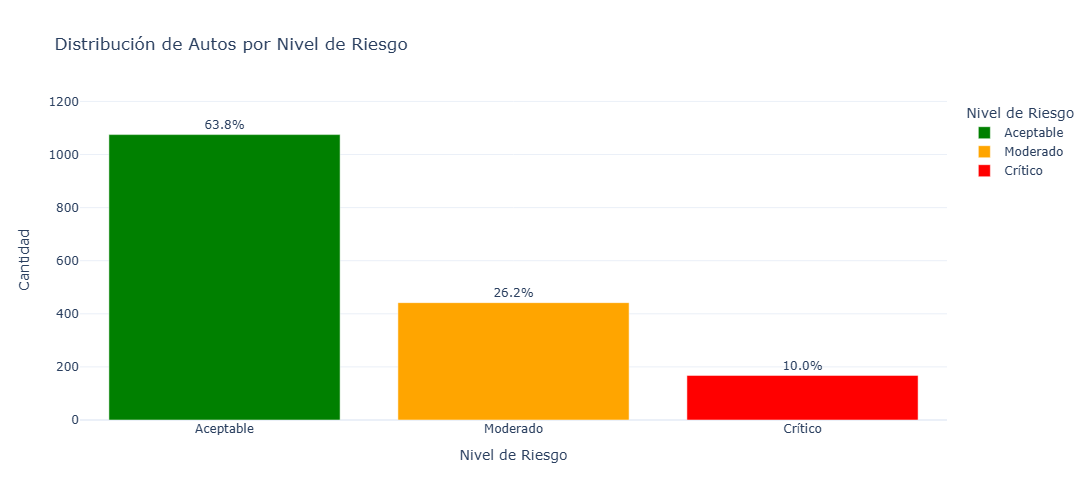

In [27]:
import plotly.express as px

# ==========================================
# GRÁFICO — DISTRIBUCIÓN DE AUTOS POR RIESGO
# ==========================================

df_riesgo = (
    df_alertas["Riesgo"]
    .value_counts()
    .reset_index()
)

df_riesgo.columns = [
    "Nivel de Riesgo",
    "Cantidad"
]

df_riesgo["Porcentaje"] = (
    df_riesgo["Cantidad"]
    / df_alertas.shape[0]
    * 100
).round(1)

color_map = {
    "Aceptable": "green",
    "Moderado": "orange",
    "Crítico": "red"
}

fig = px.bar(
    df_riesgo,
    x="Nivel de Riesgo",
    y="Cantidad",
    color="Nivel de Riesgo",
    color_discrete_map=color_map,
    text="Porcentaje",
    title="Distribución de Autos por Nivel de Riesgo"
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    height=500,
    xaxis_title="Nivel de Riesgo",
    yaxis_title="Cantidad",
    legend_title="Nivel de Riesgo"
)

fig.show()

## Descripción

Este KPI utiliza un modelo de regresión lineal que considera las variables **kilometraje, año, marca y combustible** para estimar el precio de los vehículos.

El gráfico de barras muestra la distribución de autos según tres niveles de riesgo:

* **Aceptable:** diferencia entre el precio real y el precio predicho menor o igual al error promedio (MAE).
* **Moderado:** diferencia menor o igual al doble del MAE.
* **Crítico:** diferencia mayor al doble del MAE.

Las métricas utilizadas para evaluar el desempeño del modelo son:

* **MAE (Mean Absolute Error):** indica el error promedio en pesos entre el precio real y el precio predicho.
* **RMSE (Root Mean Squared Error):** mide la magnitud del error penalizando con mayor fuerza las diferencias extremas.

Además, el selector desplegable permite visualizar tablas detalladas con los vehículos pertenecientes a cada nivel de riesgo, mostrando información relevante como marca, año, combustible y diferencia de precio.

---

## Interpretación

Este KPI permite evaluar qué tan alineados se encuentran los precios publicados con los valores estimados por el modelo.

La mayor parte de los vehículos se concentra en la categoría **Aceptable**, lo que indica que el modelo logra capturar adecuadamente las principales tendencias de valorización y depreciación presentes en el mercado.

Los vehículos clasificados como **Moderados** presentan desviaciones intermedias respecto al valor esperado, las cuales podrían explicarse por factores no considerados en el modelo, tales como el estado físico del vehículo, equipamiento adicional, historial de mantenimiento o percepción de marca.

Por otra parte, los vehículos clasificados como **Críticos** representan los casos de mayor interés para el análisis, ya que presentan diferencias superiores a dos veces el error promedio del modelo. Estas desviaciones pueden reflejar situaciones de sobrevaloración o subvaloración significativa, generando riesgos comerciales o potenciales oportunidades de negocio.

En este sentido, el KPI actúa como un sistema de alerta temprana que facilita la supervisión y priorización de casos que requieren revisión manual.

---

## Propuesta Estratégica

**Revisión obligatoria de vehículos críticos:**
Todo vehículo clasificado en la categoría crítica debe ser revisado antes de concretar una compra o venta, reduciendo el riesgo de decisiones basadas en precios alejados del valor esperado de mercado.

**Utilizar el KPI como apoyo en decisiones de compra:**
Los vehículos identificados como subvalorados pueden representar oportunidades atractivas de adquisición, permitiendo capturar valor adicional y mejorar los márgenes comerciales.

**Optimizar estrategias de venta:**
Los vehículos sobrevalorados pueden requerir ajustes de precio para mejorar su competitividad y acelerar su rotación dentro del inventario.

**Incorporar el modelo al proceso de valorización:**
Se recomienda utilizar las predicciones generadas como referencia complementaria para estandarizar criterios de tasación y fortalecer la consistencia de precios.

**Fortalecer el monitoreo continuo del mercado:**
El seguimiento periódico de este indicador permite detectar cambios en el comportamiento del mercado y reaccionar oportunamente frente a posibles desviaciones de precio.


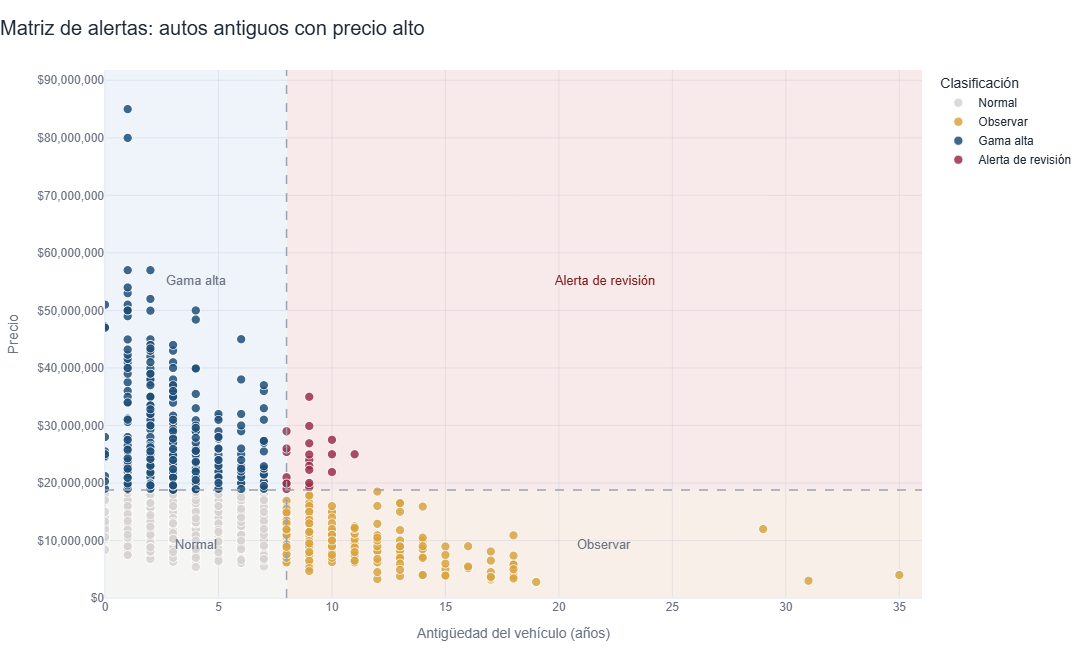

In [35]:
import pandas as pd
import plotly.express as px

# ==========================================
# KPI 2 — MATRIZ DE ALERTAS POR ANTIGÜEDAD Y PRECIO
# ==========================================

df_alerta = df.dropna(subset=["year", "precio", "marca", "modelo"]).copy()

df_alerta["year"] = pd.to_numeric(df_alerta["year"], errors="coerce")
df_alerta["precio"] = pd.to_numeric(df_alerta["precio"], errors="coerce")

anio_actual = 2026
df_alerta["antiguedad"] = anio_actual - df_alerta["year"]

# Umbrales
umbral_antiguedad = 8
umbral_precio = df_alerta["precio"].quantile(0.75)

# Clasificación igual al gráfico original
def clasificar_alerta(row):
    if row["antiguedad"] >= umbral_antiguedad and row["precio"] >= umbral_precio:
        return "Alerta de revisión"
    elif row["antiguedad"] < umbral_antiguedad and row["precio"] >= umbral_precio:
        return "Gama alta"
    elif row["antiguedad"] >= umbral_antiguedad and row["precio"] < umbral_precio:
        return "Observar"
    else:
        return "Normal"

df_alerta["Clasificación"] = df_alerta.apply(clasificar_alerta, axis=1)

paleta = {
    "Normal": "#D6D3D1",
    "Gama alta": "#1F4E79",
    "Observar": "#D9A441",
    "Alerta de revisión": "#9B2F4A"
}

x_max = max(df_alerta["antiguedad"].max() + 1, umbral_antiguedad + 2)
y_max = df_alerta["precio"].max() * 1.08

fig = px.scatter(
    df_alerta,
    x="antiguedad",
    y="precio",
    color="Clasificación",
    color_discrete_map=paleta,
    hover_data={
        "marca": True,
        "modelo": True,
        "year": True,
        "antiguedad": True,
        "precio": ":,.0f",
        "ciudad": True,
        "Clasificación": True
    },
    title="Matriz de alertas: autos antiguos con precio alto"
)

# Fondos por cuadrante
fig.add_shape(
    type="rect", x0=0, x1=umbral_antiguedad, y0=0, y1=umbral_precio,
    fillcolor="#F5F5F4", line_width=0, layer="below"
)

fig.add_shape(
    type="rect", x0=umbral_antiguedad, x1=x_max, y0=0, y1=umbral_precio,
    fillcolor="#F7EFE8", line_width=0, layer="below"
)

fig.add_shape(
    type="rect", x0=0, x1=umbral_antiguedad, y0=umbral_precio, y1=y_max,
    fillcolor="#EEF4FA", line_width=0, layer="below"
)

fig.add_shape(
    type="rect", x0=umbral_antiguedad, x1=x_max, y0=umbral_precio, y1=y_max,
    fillcolor="#F8EAEA", line_width=0, layer="below"
)

# Líneas de corte
fig.add_vline(
    x=umbral_antiguedad,
    line_dash="dash",
    line_color="#9CA3AF",
    line_width=1.5
)

fig.add_hline(
    y=umbral_precio,
    line_dash="dash",
    line_color="#9CA3AF",
    line_width=1.5
)

# Etiquetas internas
fig.add_annotation(
    x=4,
    y=umbral_precio * 0.5,
    text="Normal",
    showarrow=False,
    font=dict(size=13, color="#6B7280")
)

fig.add_annotation(
    x=(umbral_antiguedad + x_max) / 2,
    y=umbral_precio * 0.5,
    text="Observar",
    showarrow=False,
    font=dict(size=13, color="#6B7280")
)

fig.add_annotation(
    x=4,
    y=(umbral_precio + y_max) / 2,
    text="Gama alta",
    showarrow=False,
    font=dict(size=13, color="#6B7280")
)

fig.add_annotation(
    x=(umbral_antiguedad + x_max) / 2,
    y=(umbral_precio + y_max) / 2,
    text="Alerta de revisión",
    showarrow=False,
    font=dict(size=13, color="#7F1D1D")
)

fig.update_traces(
    marker=dict(
        size=9,
        opacity=0.85,
        line=dict(width=0.6, color="white")
    )
)

fig.update_layout(
    template="plotly_white",
    height=650,
    title=dict(
        text="Matriz de alertas: autos antiguos con precio alto",
        x=0,
        xanchor="left",
        font=dict(size=20, color="#1F2937")
    ),
    font=dict(family="Inter, sans-serif", color="#1F2937"),
    xaxis_title="Antigüedad del vehículo (años)",
    yaxis_title="Precio",
    legend_title="Clasificación",
    plot_bgcolor="#FFFFFF",
    paper_bgcolor="#FFFFFF",
    margin=dict(l=20, r=20, t=70, b=20)
)

fig.update_xaxes(
    range=[0, x_max],
    gridcolor="rgba(148, 163, 184, 0.18)",
    tickfont=dict(color="#6B7280"),
    title_font=dict(color="#6B7280")
)

fig.update_yaxes(
    range=[0, y_max],
    tickprefix="$",
    tickformat=",.0f",
    gridcolor="rgba(148, 163, 184, 0.18)",
    tickfont=dict(color="#6B7280"),
    title_font=dict(color="#6B7280")
)

fig.show()



La matriz expone cómo se comportan los vehículos según su **antigüedad y precio**, separando claramente los casos normales, aquellos que deben mantenerse en observación y los que requieren revisión inmediata.

Se observa que los vehículos más antiguos tienden a concentrarse en rangos de precios más bajos, comportamiento consistente con el proceso natural de depreciación esperado en el mercado automotriz. Sin embargo, aparecen ciertos casos que presentan **precios elevados pese a una antigüedad alta**, alejándose del comportamiento predominante y generando señales de alerta.

Dentro de la zona denominada **“Revisar”** se concentran publicaciones con combinaciones poco consistentes entre antigüedad y valor comercial, lo que podría reflejar situaciones de sobrevaloración, errores de publicación o condiciones particulares que requieren validación adicional.

Esta matriz funciona como una herramienta visual de apoyo para identificar rápidamente comportamientos fuera del patrón esperado y facilitar la priorización de análisis operativos.

---

## Propuesta Estratégica

**Usar esta matriz como filtro diario de control operativo:**
Permite priorizar qué publicaciones revisar primero y concentrar los esfuerzos del equipo en los vehículos con mayor nivel de riesgo.

**Revisar inmediatamente los vehículos clasificados en “Revisar”:**
Estos casos combinan alta antigüedad con precios que no siguen el comportamiento general del mercado, por lo que representan el mayor nivel de exposición comercial.

**Monitorear los casos clasificados como “Observar”:**
No requieren bloqueo automático, pero sí una validación manual para confirmar si existen condiciones particulares que justifiquen el precio.

**Incorporar esta matriz al flujo de aprobación comercial:**
Antes de publicar o incorporar vehículos al inventario, utilizar este análisis como mecanismo preventivo para reducir errores de valorización.

**Fortalecer el monitoreo continuo del inventario:**
La revisión periódica de esta matriz permite detectar cambios en tendencias de mercado y reaccionar oportunamente frente a comportamientos atípicos.


# CONCLUSIÓN AUTOTEC

El análisis desarrollado a lo largo de este proyecto permitió demostrar que la valorización de vehículos usados corresponde a un problema complejo y multivariable, donde el precio de mercado no depende de un único factor, sino de la interacción entre variables como el kilometraje, la antigüedad, la marca, el tipo de combustible y las características particulares de cada vehículo. Los resultados obtenidos evidencian que utilizar criterios generales o métodos de tasación tradicionales puede generar diferencias significativas entre el valor estimado y el precio real que el mercado está dispuesto a pagar.

La implementación de un enfoque basado en datos permitió transformar grandes volúmenes de información en conocimiento útil para la toma de decisiones. A través de los niveles estratégico, táctico y operacional, fue posible construir indicadores específicos para distintos niveles de la organización, proporcionando información relevante tanto para la planificación comercial como para el control diario de las operaciones.

A nivel estratégico, los KPI permitieron comprender el comportamiento general del mercado, identificar tendencias de valorización, analizar la participación de marcas y evaluar el impacto del kilometraje en la depreciación de los vehículos. A nivel táctico, se identificaron diferencias significativas entre combustibles, marcas y niveles de retención de valor, permitiendo detectar oportunidades de negocio y orientar la gestión del inventario. Finalmente, a nivel operacional, la incorporación de modelos predictivos y sistemas de alerta facilitó la detección de vehículos potencialmente sobrevalorados o subvalorados, fortaleciendo los procesos de revisión y control.

Uno de los principales hallazgos del proyecto fue comprobar que el kilometraje constituye uno de los factores más influyentes en la depreciación de los vehículos. Sin embargo, su efecto no es uniforme para todas las marcas ni tipos de combustible, lo que demuestra que los modelos de valorización basados únicamente en promedios generales resultan insuficientes para representar adecuadamente el comportamiento real del mercado.

Asimismo, el desarrollo del dashboard permitió integrar indicadores, análisis visuales y modelos predictivos en una única herramienta de apoyo a la decisión, facilitando la interpretación de los datos y reduciendo la dependencia de criterios subjetivos o experiencia individual.

En conclusión, este proyecto entrega una solución orientada a la toma de decisiones basada en evidencia, permitiendo mejorar los procesos de valorización de vehículos usados, reducir riesgos asociados a errores de tasación y generar una ventaja competitiva mediante el uso estratégico de los datos. De esta forma, Autotec dispone de una herramienta que transforma información dispersa en conocimiento accionable, fortaleciendo tanto la gestión comercial como la eficiencia operativa de la organización.
